## EN3160 Assignment 01 -  Intensity Transformations and Neighborhood Filtering

### Question 1

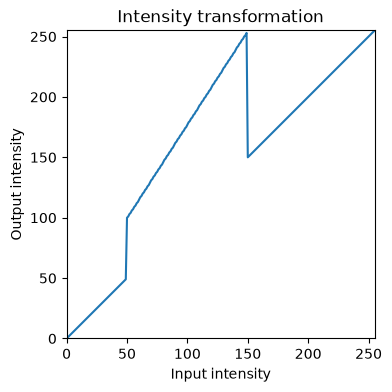

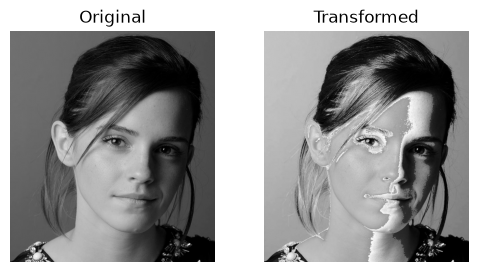

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    """
    im: grayscale image (uint8)
    breakpoints: list/array of (x, y) pairs, sorted by x.
                 Repeat an x value (e.g. (150,255),(150,150)) to create
                 a vertical discontinuity like in Fig. 1a.
    Returns: (transformed_image, lut)
    """
    bp = np.array(breakpoints, dtype=float)
    xs, ys = bp[:, 0], bp[:, 1]
    lut = np.zeros(256, dtype='uint8')

    for i in range(len(bp) - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i + 1], ys[i + 1]
        x0i, x1i = int(x0), int(x1)

        if x1i == x0i:          # vertical jump -> nothing to fill in
            continue

        seg = np.linspace(y0, y1, x1i - x0i + 1)
        if i < len(bp) - 2:     # avoid writing the shared boundary twice
            lut[x0i:x1i] = seg[:-1].astype('uint8')
        else:                   # last segment: include the final point (255)
            lut[x0i:x1i + 1] = seg.astype('uint8')

    transformed = cv.LUT(im, lut)
    return transformed, lut


# --- Reproduce the sawtooth shown in Fig. 1a ---
#breakpoints = [(0, 0), (50, 50), (150, 250), (150, 150), (255, 255)]
breakpoints = [(0, 0), (50, 50), (50, 100), (150, 255), (150,150), (255, 255)]


img_orig = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)   # <-- change filename to match your file
img_transformed, lut = intensity_transform(img_orig, breakpoints)

# Plot the transformation curve
plt.figure(figsize=(4, 4))
plt.plot(lut)
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.title('Intensity transformation')
plt.show()

# Side-by-side original vs transformed
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_orig, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_transformed, cmap='gray')
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.show()

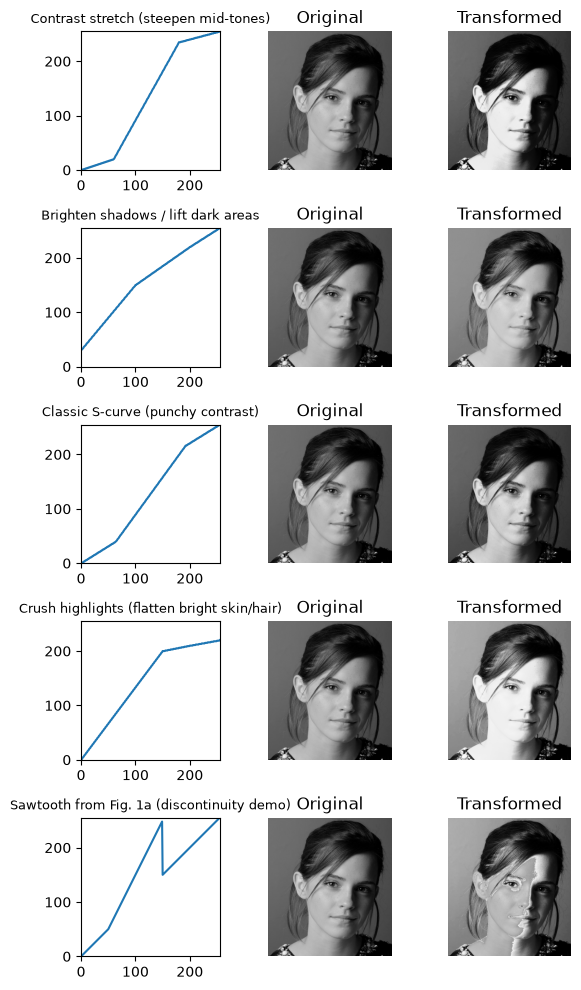

In [9]:
test_breakpoints = {
    "Contrast stretch (steepen mid-tones)": [
        (0, 0), (60, 20), (180, 235), (255, 255)
    ],
    "Brighten shadows / lift dark areas": [
        (0, 30), (100, 150), (200, 220), (255, 255)
    ],
    "Classic S-curve (punchy contrast)": [
        (0, 0), (64, 40), (128, 128), (192, 216), (255, 255)
    ],
    "Crush highlights (flatten bright skin/hair)": [
        (0, 0), (150, 200), (200, 210), (255, 220)
    ],
    "Sawtooth from Fig. 1a (discontinuity demo)": [
        (0, 0), (50, 50), (150, 250), (150, 150), (255, 255)
    ],
}

fig, axes = plt.subplots(len(test_breakpoints), 3, figsize=(6, 2 * len(test_breakpoints)))

for row, (label, bp) in enumerate(test_breakpoints.items()):
    transformed, lut = intensity_transform(img_orig, bp)

    axes[row, 0].plot(lut)
    axes[row, 0].set_xlim(0, 255); axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_title(label, fontsize=9)

    axes[row, 1].imshow(img_orig, cmap='gray')
    axes[row, 1].set_title('Original'); axes[row, 1].axis('off')

    axes[row, 2].imshow(transformed, cmap='gray')
    axes[row, 2].set_title('Transformed'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

### Question 2

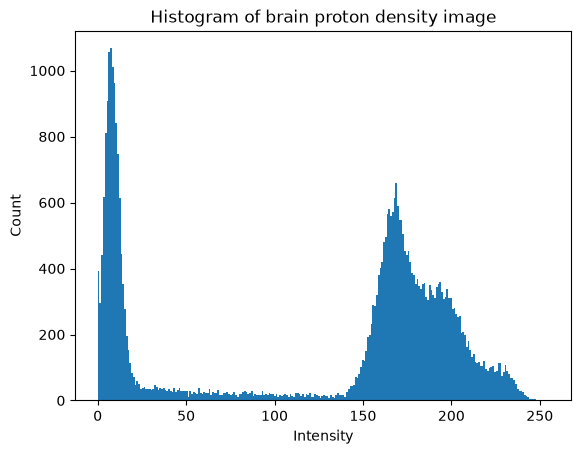

In [10]:
img_orig = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)  # <-- match your filename

plt.figure()
plt.hist(img_orig.ravel(), bins=256, range=(0, 255))
plt.title('Histogram of brain proton density image')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()

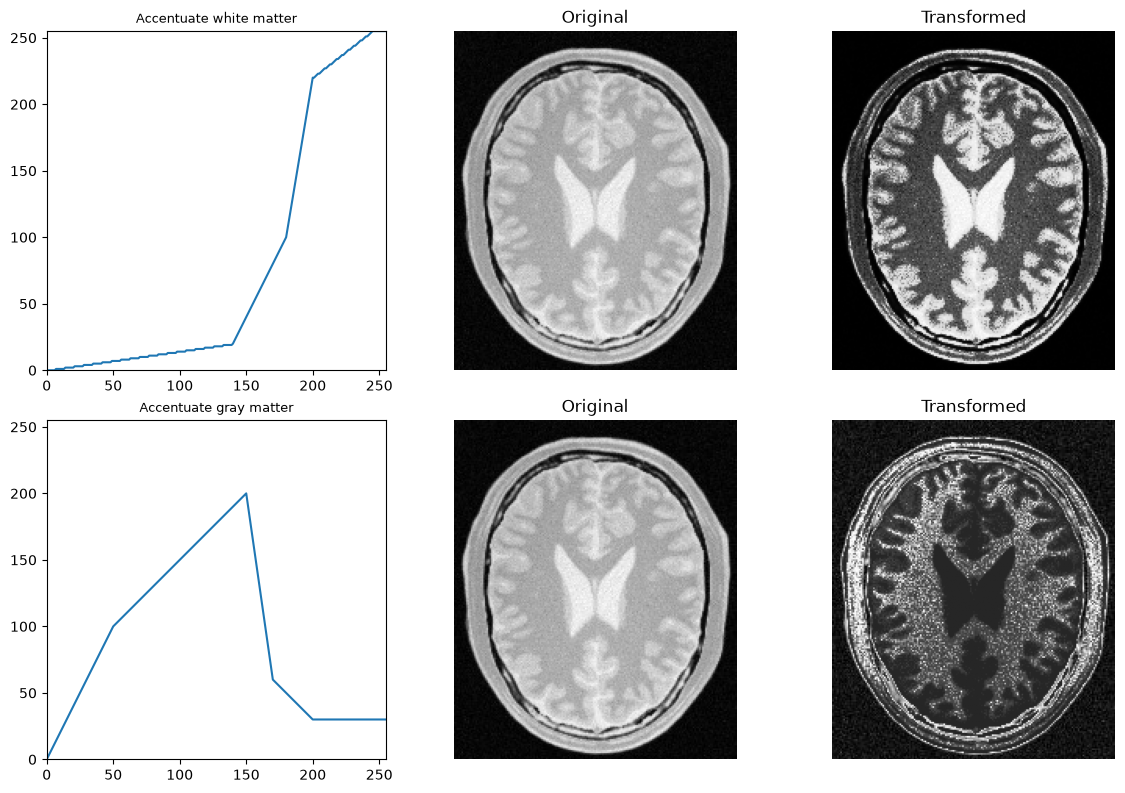

In [ ]:
transforms = {
    "Accentuate white matter": [
        (0, 0), (140, 20), (180, 100), (200, 220), (245, 255), (255, 255)
    ],
    "Accentuate gray matter": [
        (0, 0), (50, 100), (150, 200), (170, 60), (200, 30), (255, 30)
    ],
}

fig, axes = plt.subplots(len(transforms), 3, figsize=(12, 4 * len(transforms)))

for row, (label, bp) in enumerate(transforms.items()):
    transformed, lut = intensity_transform(img_orig, bp)

    axes[row, 0].plot(lut)
    axes[row, 0].set_xlim(0, 255); axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_title(label, fontsize=9)

    axes[row, 1].imshow(img_orig, cmap='gray')
    axes[row, 1].set_title('Original'); axes[row, 1].axis('off')

    axes[row, 2].imshow(transformed, cmap='gray')
    axes[row, 2].set_title('Transformed'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

### Question 3

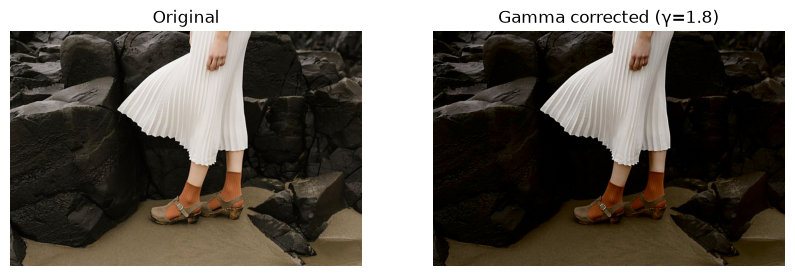

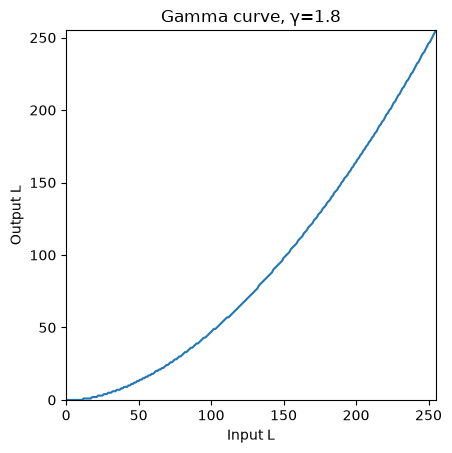

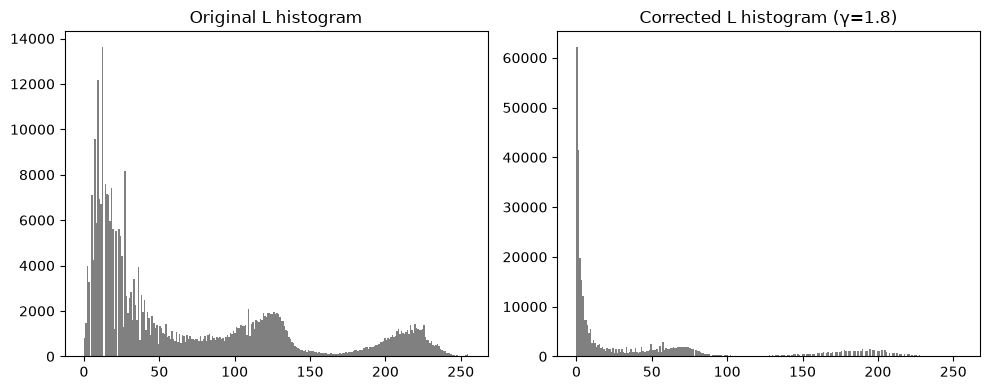

In [14]:
img_bgr = cv.imread('images/q3.jpeg', cv.IMREAD_COLOR)  # <-- match your filename
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

L, a, b = cv.split(img_lab)

gamma = 1.8   # >1 darkens midtones/shadows, <1 brightens them — pick based on your image, state it in report

# Build LUT for the gamma function (0-255 -> 0-255)
lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype='uint8')
L_corrected = cv.LUT(L, lut)

img_lab_corrected = cv.merge([L_corrected, a, b])
img_bgr_corrected = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2BGR)

# --- Display original vs corrected ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(img_bgr_corrected, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (γ={gamma})'); axes[1].axis('off')
plt.show()

# --- Gamma curve itself (nice to include in the report) ---
plt.figure()
plt.plot(lut)
plt.xlim(0, 255); plt.ylim(0, 255)
plt.gca().set_aspect('equal')
plt.xlabel('Input L'); plt.ylabel('Output L')
plt.title(f'Gamma curve, γ={gamma}')
plt.show()

# --- Histograms of L channel before and after ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original L histogram')
axes[1].hist(L_corrected.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title(f'Corrected L histogram (γ={gamma})')
plt.tight_layout()
plt.show()